In [ ]:
!pwd

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data"

In [ ]:
import os
print(os.listdir(DATA_PATH))

['CHANGES', 'dataset_description.json', 'participants.json', 'README', 'participants.tsv', '.DS_Store', 'sub-021', 'sub-019', 'sub-026', 'sub-010', 'sub-028', 'sub-017', 'sub-088', 'sub-081', 'sub-044', 'sub-043', 'sub-086', 'sub-016', 'sub-072', 'sub-075', 'sub-029', 'sub-027', 'sub-011', 'sub-018', 'sub-020', 'sub-073', 'sub-045', 'sub-042', 'sub-060', 'sub-080', 'derivatives', 'sub-074', 'sub-087', 'sub-005', 'sub-051', 'sub-067', 'sub-069', 'sub-058', 'sub-056', 'sub-033', 'sub-034', 'sub-002', 'sub-066', 'sub-068', 'sub-057', 'sub-050', 'sub-059', 'sub-032', 'sub-061', 'sub-078', 'sub-003', 'sub-004', 'sub-047', 'sub-035', 'sub-049', 'sub-040', 'sub-076', 'sub-082', 'sub-085', 'sub-071', 'sub-013', 'sub-014', 'sub-022', 'sub-025', 'sub-077', 'sub-083', 'sub-041', 'sub-070', 'sub-048', 'sub-079', 'sub-084', 'sub-046', 'sub-012', 'sub-006', 'sub-039', 'sub-024', 'sub-023', 'sub-015', 'sub-008', 'sub-037', 'sub-001', 'sub-063', 'sub-007', 'sub-036', 'sub-009', 'sub-031', 'sub-064', '

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mne numpy scipy pandas --quiet

import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy.signal import hilbert

DATA_PATH    = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data"
participants = pd.read_csv(os.path.join(DATA_PATH, "participants.tsv"), sep="\t")
GROUP_COL    = "Group"

# Mu removed
BANDS = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 25),
    "Gamma": (25, 45),
}

def band_power(raw, fmin, fmax):
    return np.mean(raw.compute_psd(fmin=fmin, fmax=fmax).get_data())

def kuramoto(raw, fmin, fmax):
    data   = raw.get_data()
    data   = mne.filter.filter_data(data, raw.info['sfreq'], fmin, fmax, verbose=False)
    phases = np.angle(hilbert(data))
    return np.mean(np.abs(np.mean(np.exp(1j * phases), axis=0)))

print("Setup done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done!


In [ ]:
results = []

for subj in os.listdir(DATA_PATH):
    if not subj.startswith("sub-"):
        continue
    eeg_path = os.path.join(DATA_PATH, subj, "eeg")
    if not os.path.exists(eeg_path):
        continue
    for f in os.listdir(eeg_path):
        if not f.endswith(".set"):
            continue
        try:
            raw   = mne.io.read_raw_eeglab(os.path.join(eeg_path, f),
                                            preload=True, verbose=False)
            row   = participants[participants['participant_id'] == subj]
            group = row[GROUP_COL].values[0] if len(row) else "unknown"
            entry = {"subject": subj, "group": group}
            for band, (fmin, fmax) in BANDS.items():
                entry[f"power_{band}"]    = band_power(raw, fmin, fmax)
                entry[f"kuramoto_{band}"] = kuramoto(raw, fmin, fmax)
            results.append(entry)
            print("Processed", subj)
        except Exception as e:
            print("Error:", subj, e)

df = pd.DataFrame(results)
print(f"\nDone! {len(df)} subjects")
print(df['group'].value_counts())

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Processed sub-021
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Processed sub-019
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Processed sub-026
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Processed sub-010
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Processed sub-028
Effective window size : 4.096 (s)
Effective window size : 4.

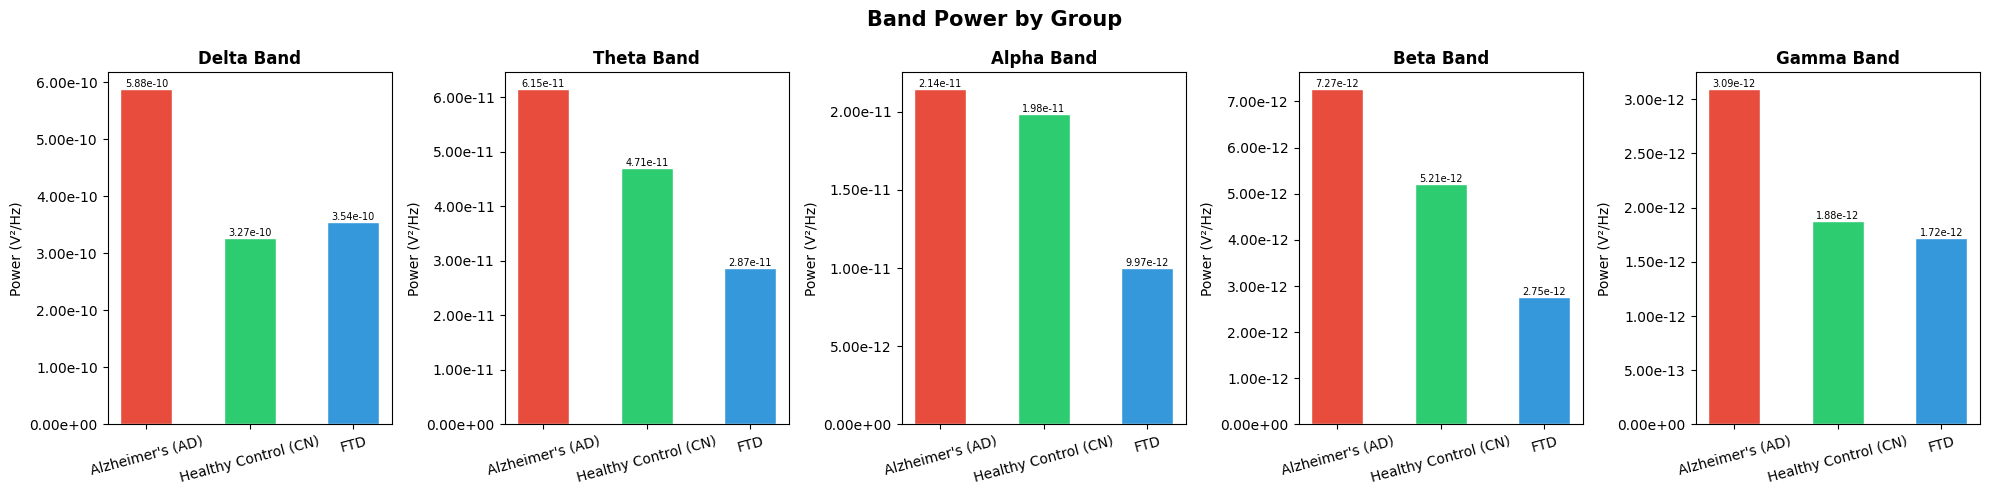

In [ ]:
power_cols    = [f"power_{b}"    for b in BANDS]
kuramoto_cols = [f"kuramoto_{b}" for b in BANDS]
groups        = df.groupby("group")[power_cols + kuramoto_cols].mean()

GROUP_COLORS = {"A": "#E74C3C", "C": "#2ECC71", "F": "#3498DB"}
GROUP_LABELS = {"A": "Alzheimer's (AD)", "C": "Healthy Control (CN)", "F": "FTD"}
band_names   = list(BANDS.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Band Power by Group", fontsize=15, fontweight='bold')

for ax, band in zip(axes, band_names):
    col    = f"power_{band}"
    grps   = [g for g in groups.index if g in GROUP_COLORS]
    vals   = [groups.loc[g, col] for g in grps]
    colors = [GROUP_COLORS[g] for g in grps]
    bars   = ax.bar([GROUP_LABELS[g] for g in grps], vals,
                    color=colors, edgecolor='white', width=0.5)
    ax.set_title(f"{band} Band", fontweight='bold')
    ax.set_ylabel("Power (V²/Hz)")
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2e}"))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.2e}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("band_power_grid.png", dpi=150, bbox_inches='tight')
plt.show()

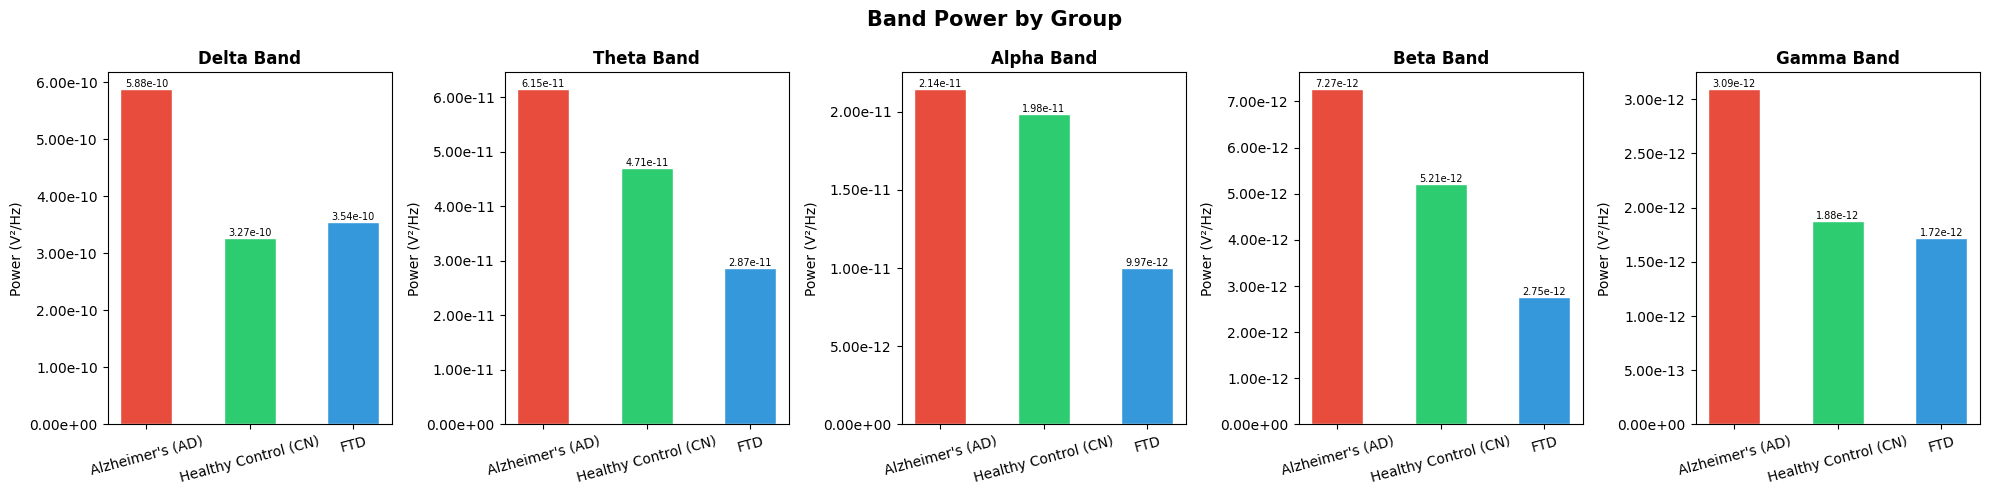

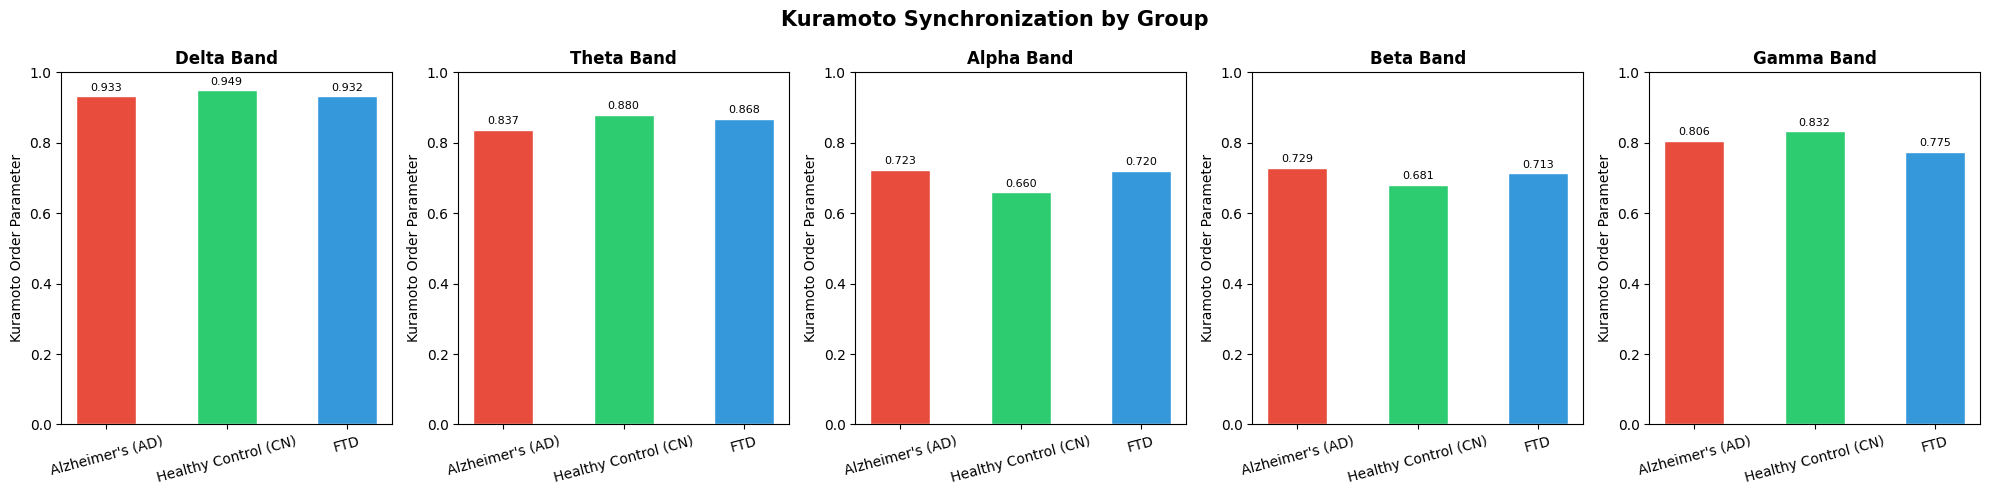


=== Band Power by Group ===
        power_Delta   power_Theta   power_Alpha    power_Beta   power_Gamma
group                                                                      
A      5.878695e-10  6.147397e-11  2.143745e-11  7.266539e-12  3.093062e-12
C      3.265645e-10  4.709680e-11  1.984466e-11  5.208213e-12  1.876876e-12
F      3.544144e-10  2.866518e-11  9.970938e-12  2.753116e-12  1.722202e-12

=== Kuramoto by Group ===
       kuramoto_Delta  kuramoto_Theta  kuramoto_Alpha  kuramoto_Beta  kuramoto_Gamma
group                                                                               
A            0.932608        0.836785        0.722729       0.728899        0.806088
C            0.948513        0.879887        0.659716       0.681479        0.832496
F            0.932487        0.868200        0.720026       0.713212        0.774969


In [ ]:
# ---- PLOT 1: Band Power 1×5 ----
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Band Power by Group", fontsize=15, fontweight='bold')

for ax, band in zip(axes, band_names):
    col    = f"power_{band}"
    grps   = [g for g in groups.index if g in GROUP_COLORS]
    vals   = [groups.loc[g, col] for g in grps]
    colors = [GROUP_COLORS[g] for g in grps]
    bars   = ax.bar([GROUP_LABELS[g] for g in grps], vals,
                    color=colors, edgecolor='white', width=0.5)
    ax.set_title(f"{band} Band", fontweight='bold')
    ax.set_ylabel("Power (V²/Hz)")
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2e}"))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.2e}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("band_power_grid.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- PLOT 2: Kuramoto 1×5 ----
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Kuramoto Synchronization by Group", fontsize=15, fontweight='bold')

for ax, band in zip(axes, band_names):
    col    = f"kuramoto_{band}"
    grps   = [g for g in groups.index if g in GROUP_COLORS]
    vals   = [groups.loc[g, col] for g in grps]
    colors = [GROUP_COLORS[g] for g in grps]
    bars   = ax.bar([GROUP_LABELS[g] for g in grps], vals,
                    color=colors, edgecolor='white', width=0.5)
    ax.set_title(f"{band} Band", fontweight='bold')
    ax.set_ylabel("Kuramoto Order Parameter")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("kuramoto_grid.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Band Power by Group ===")
print(df.groupby("group")[power_cols].mean().to_string())
print("\n=== Kuramoto by Group ===")
print(df.groupby("group")[kuramoto_cols].mean().to_string())

Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


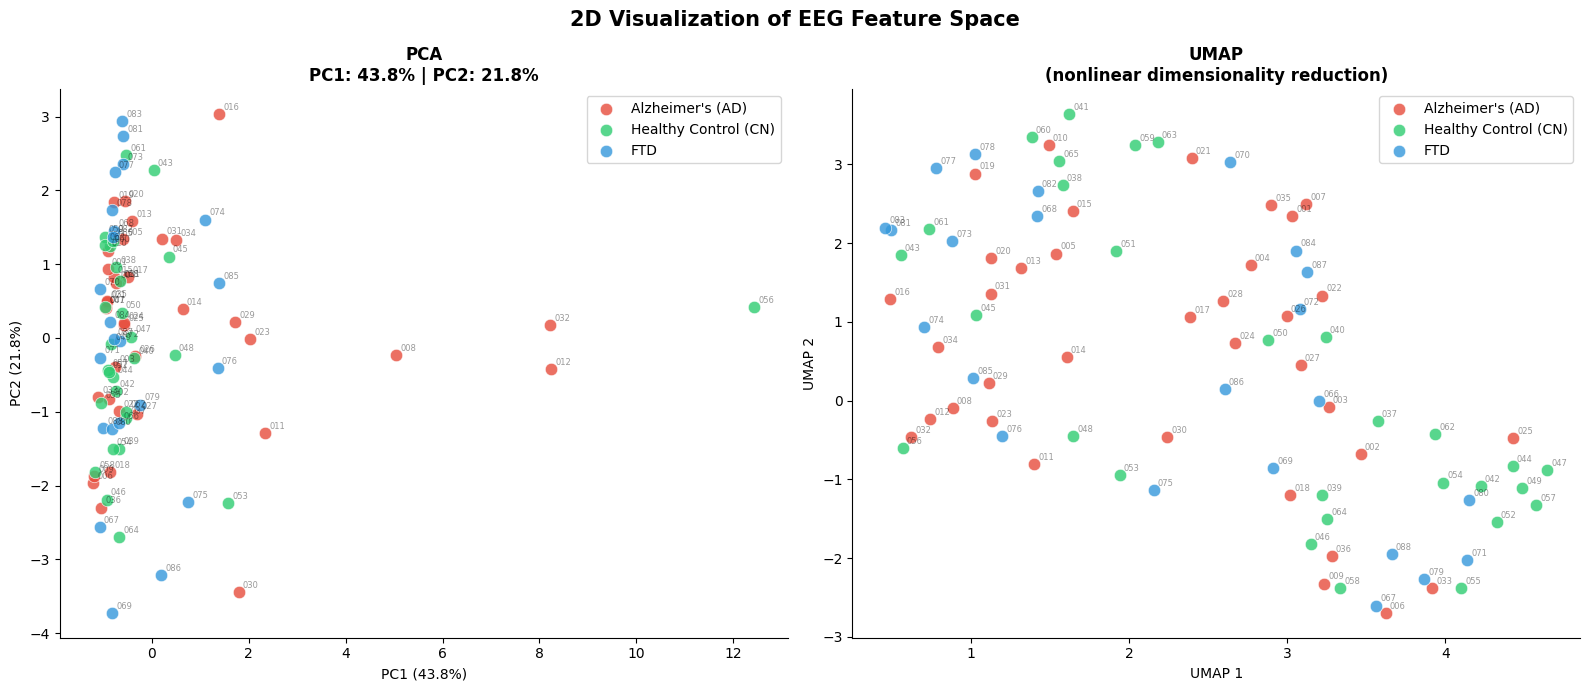

Done!


In [ ]:
!pip install umap-learn --quiet
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = power_cols + kuramoto_cols
X        = df[feature_cols].values
y        = df["group"].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("2D Visualization of EEG Feature Space", fontsize=15, fontweight="bold")

# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_

ax = axes[0]
for group in ["A", "C", "F"]:
    mask = y == group
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=GROUP_COLORS[group], label=GROUP_LABELS[group],
               alpha=0.8, s=80, edgecolors="white", linewidth=0.5)
ax.set_title(f"PCA\nPC1: {var[0]:.1%} | PC2: {var[1]:.1%}", fontweight="bold")
ax.set_xlabel(f"PC1 ({var[0]:.1%})")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (x, yy) in enumerate(X_pca):
    ax.annotate(df["subject"].values[i].replace("sub-", ""),
                (x, yy), fontsize=6, alpha=0.4,
                xytext=(3, 3), textcoords="offset points")

# UMAP
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)

ax = axes[1]
for group in ["A", "C", "F"]:
    mask = y == group
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=GROUP_COLORS[group], label=GROUP_LABELS[group],
               alpha=0.8, s=80, edgecolors="white", linewidth=0.5)
ax.set_title("UMAP\n(nonlinear dimensionality reduction)", fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (x, yy) in enumerate(X_umap):
    ax.annotate(df["subject"].values[i].replace("sub-", ""),
                (x, yy), fontsize=6, alpha=0.4,
                xytext=(3, 3), textcoords="offset points")

plt.tight_layout()
plt.savefig("pca_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done!")

Mounted at /content/drive
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>
Using matplotlib as 2D backend.


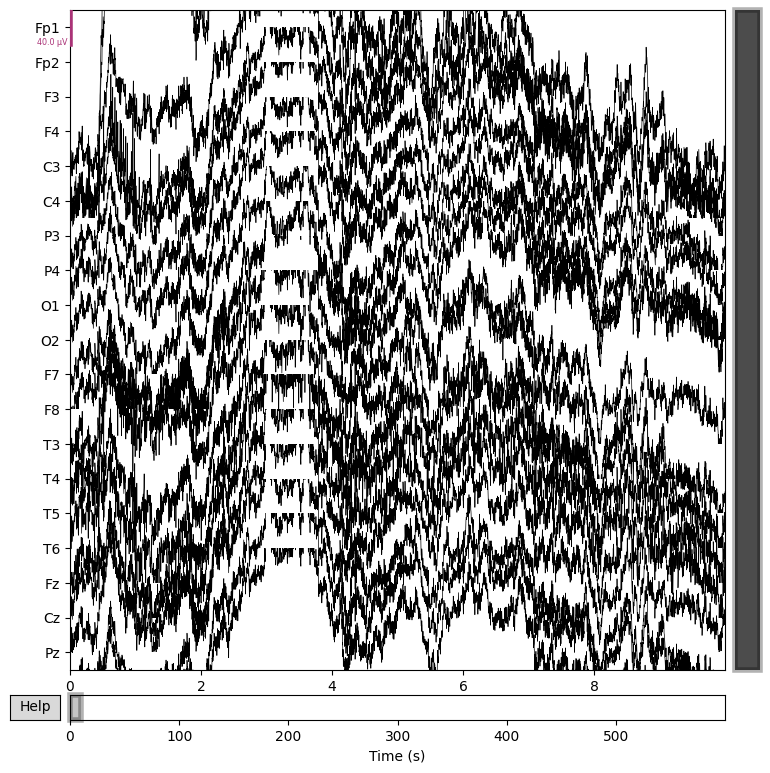

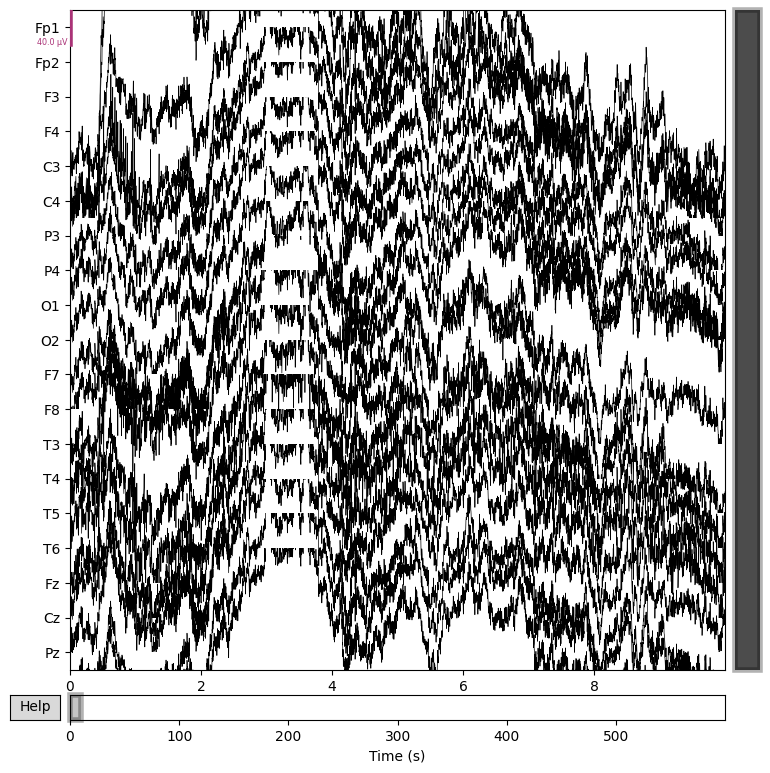

In [ ]:
!pip install mne --quiet
import mne

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data"

raw = mne.io.read_raw_eeglab(
    DATA_PATH + "/sub-001/eeg/sub-001_task-eyesclosed_eeg.set",
    preload=True
)

# Basic info
print(raw.info)

# Plot the raw brainwaves
raw.plot(duration=10, n_channels=19)


In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data"

# See all subjects
print(os.listdir(DATA_PATH))

# See one subject's files
print(os.listdir(DATA_PATH + "/sub-001/eeg"))

['CHANGES', 'dataset_description.json', 'participants.json', 'README', 'participants.tsv', '.DS_Store', 'sub-021', 'sub-019', 'sub-026', 'sub-010', 'sub-028', 'sub-017', 'sub-088', 'sub-081', 'sub-044', 'sub-043', 'sub-086', 'sub-016', 'sub-072', 'sub-075', 'sub-029', 'sub-027', 'sub-011', 'sub-018', 'sub-020', 'sub-073', 'sub-045', 'sub-042', 'sub-060', 'sub-080', 'derivatives', 'sub-074', 'sub-087', 'sub-005', 'sub-051', 'sub-067', 'sub-069', 'sub-058', 'sub-056', 'sub-033', 'sub-034', 'sub-002', 'sub-066', 'sub-068', 'sub-057', 'sub-050', 'sub-059', 'sub-032', 'sub-061', 'sub-078', 'sub-003', 'sub-004', 'sub-047', 'sub-035', 'sub-049', 'sub-040', 'sub-076', 'sub-082', 'sub-085', 'sub-071', 'sub-013', 'sub-014', 'sub-022', 'sub-025', 'sub-077', 'sub-083', 'sub-041', 'sub-070', 'sub-048', 'sub-079', 'sub-084', 'sub-046', 'sub-012', 'sub-006', 'sub-039', 'sub-024', 'sub-023', 'sub-015', 'sub-008', 'sub-037', 'sub-001', 'sub-063', 'sub-007', 'sub-036', 'sub-009', 'sub-031', 'sub-064', '

In [ ]:
import pandas as pd

participants = pd.read_csv(DATA_PATH + "/participants.tsv", sep="\t")
print(participants)

   participant_id Gender  Age Group  MMSE
0         sub-001      F   57     A    16
1         sub-002      F   78     A    22
2         sub-003      M   70     A    14
3         sub-004      F   67     A    20
4         sub-005      M   70     A    22
..            ...    ...  ...   ...   ...
83        sub-084      F   71     F    24
84        sub-085      M   64     F    26
85        sub-086      M   49     F    26
86        sub-087      M   73     F    24
87        sub-088      M   55     F    24

[88 rows x 5 columns]
